# Lakehouse Ingestion Metadata - Impact Plan Analysis

This notebook provides a comprehensive analysis of data ingestion impacts, gaps, and strategic planning for the modernization initiative.

## Overview

- **Current State**: Validation of working SORs and metadata coverage
- **Gap Analysis**: Strategic vs tactical gaps identification
- **Future State Vision**: MVM tactical feeds feeding AI-ready knowledge graph
- **Triples Analysis**: Authoritative flows between SOR, iPaaS, and OLTP systems

In [6]:
# Imports and Configuration
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display, Image

# Configure matplotlib for better visuals
plt.style.use('default')
%matplotlib inline

# Configuration: Choose which version of the master sheet to use
USE_V2 = False  # Set to True to use v2 template with Triples Analysis


## Data Loading

Load the master metadata sheet and all relevant data tables.


In [7]:
# Load master sheet (replace path if needed)
import os

if USE_V2:
    # Try new file name first, then fall back to old name for compatibility
    if os.path.exists('Metadata_Master_Sheet_v2_2026.xlsx'):
        master_file = 'Metadata_Master_Sheet_v2_2026.xlsx'
    elif os.path.exists('Metadata_Master_Sheet_Template_v2.xlsx'):
        master_file = 'Metadata_Master_Sheet_Template_v2.xlsx'
    else:
        master_file = 'Metadata_Master_Sheet_v2_2026.xlsx'  # Default to new name
else:
    # Try new file name first, then fall back to old name
    if os.path.exists('Metadata_Master_Sheet_v2_2026.xlsx'):
        master_file = 'Metadata_Master_Sheet_v2_2026.xlsx'
    elif os.path.exists('Metadata_Master_Sheet_Template.xlsx'):
        master_file = 'Metadata_Master_Sheet_Template.xlsx'
    else:
        master_file = 'Metadata_Master_Sheet_v2_2026.xlsx'  # Default to new name

print(f"Loading data from: {master_file}")

try:
    # Load all 7 tabs per specification
    sources = pd.read_excel(master_file, sheet_name='Sources')
    targets = pd.read_excel(master_file, sheet_name='Targets')
    pipelines = pd.read_excel(master_file, sheet_name='Pipelines')
    gaps = pd.read_excel(master_file, sheet_name='Gaps & Actions')
    glossary = pd.read_excel(master_file, sheet_name='Glossary')
    gap_analysis = pd.read_excel(master_file, sheet_name='Gap Analysis')
    
    # Load triples if using v2
    if USE_V2:
        triples = pd.read_excel(master_file, sheet_name='Triples Analysis')
        print("Triples Analysis loaded")
    else:
        triples = None
    
    print("All data sheets loaded successfully")
    print(f"  - Sources: {len(sources)} rows")
    print(f"  - Targets: {len(targets)} rows")
    print(f"  - Pipelines: {len(pipelines)} rows")
    print(f"  - Gaps: {len(gaps)} rows")
    print(f"  - Glossary: {len(glossary)} rows")
    print(f"  - Gap Analysis: {len(gap_analysis)} rows")
    if triples is not None:
        print(f"  - Triples: {len(triples)} rows")
    
    # Basic validation: Check for required columns
    required_sources_cols = ['SOR_Name', 'Source_Table_or_View_Name', 'Ingestion_Pattern']
    missing_cols = [col for col in required_sources_cols if col not in sources.columns]
    if missing_cols:
        print(f"Warning: Missing columns in Sources: {missing_cols}")
    else:
        print("Sources tab structure validated")
        
except FileNotFoundError:
    print(f"Error: File '{master_file}' not found.")
    print(f"Current directory: {os.getcwd()}")
    print("Available Excel files:")
    excel_files = [f for f in os.listdir('.') if f.endswith('.xlsx')]
    if excel_files:
        for f in excel_files:
            print(f"  - {f}")
    else:
        print("  (no Excel files found)")
    print("\nPlease ensure the Excel file is in the same directory as this notebook.")
    print("Or update the master_file path in the cell above.")
    raise
except Exception as e:
    print(f"Error loading data: {e}")
    raise


Loading data from: Metadata_Master_Sheet_v2_2026.xlsx
All data sheets loaded successfully
  - Sources: 2 rows
  - Targets: 2 rows
  - Pipelines: 2 rows
  - Gaps: 4 rows
  - Glossary: 4 rows
  - Gap Analysis: 4 rows
Sources tab structure validated


## Section 1: Current State Overview

Fact-based validation of what's working: Key SORs and raw metadata coverage.


In [8]:
# Current State: Key SORs and Raw Metadata Coverage
print('Current State: Key SORs and Raw Metadata Coverage')
print('Examples: Duck Creek/Clarity, Guidewire Parquet CDC\n')
display(sources.head(10))


Current State: Key SORs and Raw Metadata Coverage
Examples: Duck Creek/Clarity, Guidewire Parquet CDC



,SOR_Name,Source_Table_or_View_Name,Database_or_Schema,Approx_Daily_Records_or_Size,Ingestion_Pattern,Key_Columns_with_Types,Primary_Key_or_Unique_ID,Business_Meanings_Key_Terms,PII_or_Sensitive_Flag,Current_Use_Reports_or_Rate_Cases,SME_Notes_Questions_Gaps,Filled_By_Date
0,Duck Creek Clarity,POLICY_CURATED,CLARITY_DB.POLICY_LAYER,~50k recs / 200 MB daily,Batch Export or API,"PolicyGUID:VARCHAR, EffectiveDate:DATE, Premiu...",PolicyGUID,PolicyGUID = Unique system ID; Premium = Annua...,"Yes – InsuredName, Address",Rate case exposure by state; Sales Summary,History in separate view? Deletes?,Jane Doe – 2026-02-05
1,Guidewire,POLICY_CDC_PARQUET,GW_CDC_EXPORT,~100k recs / 500 MB daily,CDC,"PolicyID:VARCHAR, TransactionDate:TIMESTAMP, C...",PolicyID + TransactionDate,PolicyID = Guidewire policy identifier; Change...,Yes – Customer data in PolicyData struct,Real-time policy change tracking; Audit reports,Auto Loader compatible?,John Smith – 2026-02-06


In [9]:
# Working Foundations: Patterns like CDC/Auto Loader
print('Working Foundations: Patterns like CDC/Auto Loader are defined for raw ingestion.\n')
working_pipelines = pipelines[pipelines['Status'].isin(['Planned', 'Complete'])]
print(f"Found {len(working_pipelines)} working/planned pipelines:")
display(working_pipelines)


Working Foundations: Patterns like CDC/Auto Loader are defined for raw ingestion.

Found 2 working/planned pipelines:


,Pipeline_ID,SOR_Name,Source_Table,Bronze_Table,Pattern,iPaaS_Required,Estimated_Effort,Risks_AntiPattern,Status
0,DC_CLARITY_POLICY_BATCH,Duck Creek Clarity,POLICY_CURATED,bronze_duck_creek_policy_curated,Batch Export,Yes (API mediation),Medium,Partner constraints,Planned
1,GW_POLICY_CDC,Guidewire,POLICY_CDC_PARQUET,bronze_guidewire_policy_cdc,CDC,No,Low,NaN,Planned


### Incorporating Past Work

Reference previous slides and diagrams for context.


In [10]:
# Wrangle Past Slides: Insert your old work visuals here
# Uncomment and add your files as needed
# display(Image('past_slide1.png'))
# display(Image('past_slide2.png'))


## Section 2: Gap Analysis and Vital Gaps

Data-driven analysis of strategic vs tactical gaps.


Vital Gaps: Closing/Closed/Needs Closure for Proper Foundation



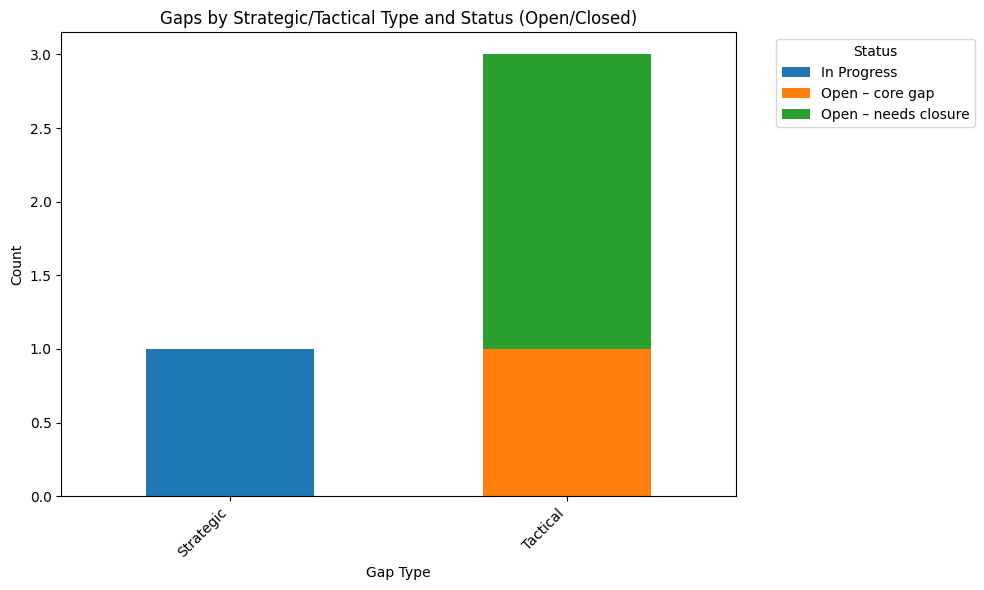

In [11]:
# Visualize gaps by type/status
print('Vital Gaps: Closing/Closed/Needs Closure for Proper Foundation\n')

gap_counts = gaps.groupby('Type (Strategic/Tactical)')['Status'].value_counts().unstack().fillna(0)
gap_counts.plot(kind='bar', stacked=True, 
                title='Gaps by Strategic/Tactical Type and Status (Open/Closed)',
                figsize=(10, 6))
plt.ylabel('Count')
plt.xlabel('Gap Type')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [12]:
# Closed/Closing: Validate progress
closed_gaps = gaps[gaps['Status'].isin(['Closed', 'In Progress'])]
print(f'Closed/Closing Gaps (Foundation Strengthening): {len(closed_gaps)} items\n')
display(closed_gaps)


Closed/Closing Gaps (Foundation Strengthening): 1 items



,Area,Gap Description,Type (Strategic/Tactical),Priority,Status,Action Plan,Owner,Deadline,Notes
1,Glossary,No centralized BA/architect glossary; mapping ...,Strategic,Medium,In Progress,Seed from MVM Business Meanings column,Cognizant / BA,2026-02-21,Foundation for KG


In [13]:
# Needs Closure: Priority tactical gaps
open_gaps = gaps[gaps['Status'] == 'Open']
print(f'Vital Gaps Needing Closure: {len(open_gaps)} items')
print('Examples: Tactical Priorities - DD Access, iPaaS BU Mandates\n')
display(open_gaps)


Vital Gaps Needing Closure: 0 items
Examples: Tactical Priorities - DD Access, iPaaS BU Mandates



,Area,Gap Description,Type (Strategic/Tactical),Priority,Status,Action Plan,Owner,Deadline,Notes


In [14]:
# Full Gap Analysis Table (Current vs Future)
print('Gap Analysis: Current vs Future State')
print('Strategic: AI-Ready KG | Tactical: MVM Foundation\n')
display(gap_analysis)


Gap Analysis: Current vs Future State
Strategic: AI-Ready KG | Tactical: MVM Foundation



,Area,Current State,Future State,Gap Description,Type (Strategic/Tactical),Priority,Action Plan,Owner,Deadline
0,Metadata Collection,"Messy Cognizant Excels, partial DDs, no structure","Structured MVM sheets per SOR, feeding KG",DDs not pulled from vendor portals,Tactical,High,"Delegate DD pulls: Duck Creek Support Portal, ...",SOR SMEs,2026-02-14
1,Glossary,Scattered or none; seeded minimally from MVM,AI-ready KG with full business terms & lineage,No centralized BA/architect glossary; mapping ...,Strategic,Medium,Seed from MVM Business Meanings column,Cognizant / BA,2026-02-21
2,iPaaS Flow Mandates,"Unclear BU rules; ""triples"" not mapped",Defined per-SOR authoritative flows (#1–#3),BU relation to iPaaS undefined; why #3?,Tactical,High,Define BU/iPaaS mandates via questionnaire,iPaaS SME / BU,2026-02-14
3,Triples Problem Flows,Unknown authoritative patterns,Mapped #1–#3 per pipeline; justified #3 loops,Why OLTP feedback if SoR → lakehouse covered?,Tactical,High,Map #1–#3 per pipeline; justify #3 loops,iPaaS / BU SMEs,2026-02-14


## Section 3: Future State Vision

MVM (Tactical Raw Ingestion) feeds AI-Ready KG (Strategic).


In [15]:
# Future State Vision: Glossary seeds feeding KG
print('Future State Vision: MVM (Tactical Raw Ingestion) Feeds AI-Ready KG (Strategic)\n')
kg_preview = glossary[['Term', 'Definition', 'Category']].head(10)
print('Glossary Seeds Feeding KG:')
print('(Vision includes glossaries, but tactical gaps like mapping need attention)\n')
display(kg_preview)


Future State Vision: MVM (Tactical Raw Ingestion) Feeds AI-Ready KG (Strategic)

Glossary Seeds Feeding KG:
(Vision includes glossaries, but tactical gaps like mapping need attention)



,Term,Definition,Category
0,PolicyGUID,Unique system-generated policy identifier,Field Meaning
1,Premium,Annual policy premium amount,Field Meaning
2,CDC,Change Data Capture - incremental data extract...,Ingestion Pattern
3,Bronze Layer,Raw append-only data layer in medallion archit...,Architecture


## Section 4: Tactical and Strategic Plan


In [16]:
# Tactical Plan: Close MVM Gaps
print('Tactical Plan: Close MVM Gaps')
print('Examples: Delegate DD Pulls, Fill Templates Ã¢â‚¬â€ Foundation for Raw Ingestion\n')
tactical = gap_analysis[gap_analysis['Type (Strategic/Tactical)'] == 'Tactical']
print(f"Found {len(tactical)} tactical items:")
display(tactical)


Tactical Plan: Close MVM Gaps
Examples: Delegate DD Pulls, Fill Templates Ã¢â‚¬â€ Foundation for Raw Ingestion

Found 3 tactical items:


,Area,Current State,Future State,Gap Description,Type (Strategic/Tactical),Priority,Action Plan,Owner,Deadline
0,Metadata Collection,"Messy Cognizant Excels, partial DDs, no structure","Structured MVM sheets per SOR, feeding KG",DDs not pulled from vendor portals,Tactical,High,"Delegate DD pulls: Duck Creek Support Portal, ...",SOR SMEs,2026-02-14
2,iPaaS Flow Mandates,"Unclear BU rules; ""triples"" not mapped",Defined per-SOR authoritative flows (#1–#3),BU relation to iPaaS undefined; why #3?,Tactical,High,Define BU/iPaaS mandates via questionnaire,iPaaS SME / BU,2026-02-14
3,Triples Problem Flows,Unknown authoritative patterns,Mapped #1–#3 per pipeline; justified #3 loops,Why OLTP feedback if SoR → lakehouse covered?,Tactical,High,Map #1–#3 per pipeline; justify #3 loops,iPaaS / BU SMEs,2026-02-14


In [17]:
# Strategic Plan: Build AI-Ready KG
print('Strategic Plan: Build AI-Ready KG from MVM/Glossary')
print('Examples: Feed GraphRAG, Manage Changes via Governance\n')
strategic = gap_analysis[gap_analysis['Type (Strategic/Tactical)'] == 'Strategic']
print(f"Found {len(strategic)} strategic items:")
display(strategic)


Strategic Plan: Build AI-Ready KG from MVM/Glossary
Examples: Feed GraphRAG, Manage Changes via Governance

Found 1 strategic items:


,Area,Current State,Future State,Gap Description,Type (Strategic/Tactical),Priority,Action Plan,Owner,Deadline
1,Glossary,Scattered or none; seeded minimally from MVM,AI-ready KG with full business terms & lineage,No centralized BA/architect glossary; mapping ...,Strategic,Medium,Seed from MVM Business Meanings column,Cognizant / BA,2026-02-21


### Data Quality Summary

Quick validation of data completeness and quality metrics.


In [18]:
# Data Quality Summary
print("=" * 80)
print("DATA QUALITY SUMMARY")
print("=" * 80)

# Sources completeness
if 'Filled_By_Date' in sources.columns:
    filled_sources = sources['Filled_By_Date'].notna().sum()
    total_sources = len(sources)
    print(f"\nSources Tab: {filled_sources}/{total_sources} rows filled ({filled_sources/total_sources*100:.1f}%)")

# Gaps status summary
if 'Status' in gaps.columns:
    gap_status = gaps['Status'].value_counts()
    print(f"\nGaps Status Distribution:")
    for status, count in gap_status.items():
        print(f"  - {status}: {count}")

# Pipeline status summary
if 'Status' in pipelines.columns:
    pipeline_status = pipelines['Status'].value_counts()
    print(f"\nPipeline Status Distribution:")
    for status, count in pipeline_status.items():
        print(f"  - {status}: {count}")

# Glossary terms count
print(f"\nGlossary: {len(glossary)} terms seeded")

# Triples coverage (if available)
if USE_V2 and triples is not None:
    if 'SOR_Pipeline' in triples.columns:
        print(f"\nTriples Analysis: {len(triples)} pipelines mapped")
        # Count flows
        flow1_count = triples['Flow_1_Direct_to_SoR_Lakehouse'].str.contains('Yes', na=False).sum() if 'Flow_1_Direct_to_SoR_Lakehouse' in triples.columns else 0
        flow2_count = triples['Flow_2_Via_iPaaS_to_SoR'].str.contains('Yes', na=False).sum() if 'Flow_2_Via_iPaaS_to_SoR' in triples.columns else 0
        flow3_count = triples['Flow_3_iPaaS_to_OLTP'].str.contains('Yes', na=False).sum() if 'Flow_3_iPaaS_to_OLTP' in triples.columns else 0
        print(f"  - Flow #1 (Direct): {flow1_count}")
        print(f"  - Flow #2 (Via iPaaS): {flow2_count}")
        print(f"  - Flow #3 (iPaaSâ†’OLTP): {flow3_count}")

print("=" * 80)


DATA QUALITY SUMMARY

Sources Tab: 2/2 rows filled (100.0%)

Gaps Status Distribution:
  - Open – needs closure: 2
  - In Progress: 1
  - Open – core gap: 1

Pipeline Status Distribution:
  - Planned: 2

Glossary: 4 terms seeded


## Section 5: Triples Analysis (V2 Only)

The "Triples Problem" Ã¢â‚¬â€ Authoritative flows between SOR, iPaaS, and OLTP systems.


In [19]:
# Triples Problem Overview (only if using v2)
if USE_V2 and triples is not None:
    print('Clearer Gap Statement: The "Triples Problem" Ã¢â‚¬â€ Authoritative Flows Between SOR, iPaaS, OLTP\n')
    display(triples.head(10))
else:
    print("Triples analysis requires v2 template. Set USE_V2 = True to enable.")


Triples analysis requires v2 template. Set USE_V2 = True to enable.


In [21]:
# Visualize Triples Flows
if USE_V2 and triples is not None:
    flow_columns = ['Flow #1: Direct to SoR/Lakehouse?', 
                     'Flow #2: Via iPaaS to SoR?', 
                     'Flow #3: iPaaS to OLTP?']
    
    flow_counts = triples[flow_columns].apply(pd.value_counts).fillna(0)
    flow_counts.plot(kind='bar', 
                     title='Triples Flows Coverage (Yes/No by Type)',
                     figsize=(10, 6))
    plt.ylabel('Count of SORs/Pipelines')
    plt.xlabel('Flow Type')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Response')
    plt.tight_layout()
    plt.show()


In [22]:
# Simple DAG Preview: Operational Feedback Loops
if USE_V2 and triples is not None:
    G = nx.DiGraph()
    
    for _, row in triples.iterrows():
        sor = row['SOR/Pipeline']
        
        if pd.notna(row['Flow #1: Direct to SoR/Lakehouse?']) and 'Yes' in str(row['Flow #1: Direct to SoR/Lakehouse?']):
            G.add_edge(sor, 'Lakehouse SoR (Direct Raw)')
        
        if pd.notna(row['Flow #2: Via iPaaS to SoR?']) and 'Yes' in str(row['Flow #2: Via iPaaS to SoR?']):
            G.add_edge(sor, 'iPaaS', label='Mediation')
            G.add_edge('iPaaS', 'Lakehouse SoR')
        
        if pd.notna(row['Flow #3: iPaaS to OLTP?']) and 'Yes' in str(row['Flow #3: iPaaS to OLTP?']):
            G.add_edge('iPaaS', 'OLTP (Feedback)', label='Operational Sync')
    
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=2, iterations=50)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', 
            node_size=2000, font_size=10, font_weight='bold',
            arrows=True, arrowsize=20, edge_color='gray')
    
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8)
    
    plt.title('Triples Flows DAG: Why OLTP Loops\n(Analytical Lakehouse Needs Operational Feedback)',
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


## Summary and Key Insights

This analysis is fact-based (from MVM data) and data-driven (queries/visuals). Support is needed to close vital gaps for modernization success.


In [ ]:
# Final Summary
print("=" * 80)
print("KEY MESSAGE")
print("=" * 80)
print("\nThis analysis is:")
print("  Ã¢â‚¬Â¢ Fact-based (from MVM data)")
print("  Ã¢â‚¬Â¢ Data-driven (queries/visuals)")
print("  Ã¢â‚¬Â¢ Strategic (AI-Ready KG vision)")
print("  Ã¢â‚¬Â¢ Tactical (MVM foundation gaps)")
print("\nSupport needed to close vital gaps for modernization success.")
print("=" * 80)


### Targets Mapping Summary

Review of source-to-target mappings for bronze layer.


In [23]:
# Targets Summary
if 'Bronze_Table_Name' in targets.columns:
    print("Targets Mapping Summary\n")
    print(f"Total source-to-target mappings: {len(targets)}")
    
    if 'Append_Only' in targets.columns:
        append_only_count = targets['Append_Only'].str.contains('Yes', case=False, na=False).sum()
        print(f"Append-only bronze tables: {append_only_count}/{len(targets)}")
    
    if 'Gap_Flag' in targets.columns:
        gap_count = targets['Gap_Flag'].str.contains('Yes', case=False, na=False).sum()
        print(f"Targets with gaps flagged: {gap_count}")
    
    print("\nSample target mappings:")
    display_cols = [col for col in ['SOR_Name', 'Source_Table_or_View', 'Bronze_Table_Name', 'Append_Only'] 
                    if col in targets.columns]
    if display_cols:
        display(targets[display_cols].head(10))
else:
    print("âš  Targets tab structure may not match specification")
    print(f"Available columns: {list(targets.columns)}")


Targets Mapping Summary

Total source-to-target mappings: 2
Append-only bronze tables: 2/2
Targets with gaps flagged: 0

Sample target mappings:


,SOR_Name,Source_Table_or_View,Bronze_Table_Name,Append_Only
0,Duck Creek Clarity,POLICY_CURATED,bronze_duck_creek_policy_curated,Yes
1,Guidewire,POLICY_CDC_PARQUET,bronze_guidewire_policy_cdc,Yes
